In [56]:
from sklearn.linear_model import BayesianRidge, LinearRegression
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [57]:
forecasting_summary = pd.read_csv("../../data/master_data/latent_class_forecasting_data.csv")

forecasting_summary["calendar_year"] = forecasting_summary["calendar_year"].astype(int)

In [58]:
INCLUDED_YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023]

FORECAST_YEARS = [2024, 2025, 2026, 2027]

In [59]:
class_names = {
    0:  "Middle-aged Working Fathers",
    1:  "Highly Educated Working Mothers",
    2:  "Professional Fathers",
    3:  "Professional Part-time Working Mothers",
    4:  "Later-career Middle Class Workers",
    5:  "Highly Educated Early Retirees",
    6:  "Black Middle-aged Professional Women",
    7:  "White British Retirees",
    8:  "Students in Shared Housing",
    9:  "Young Middle Class Workers",
    10: "Motivated Young Professional Men",
    11: "Graduate Professionals in Shared Housing",
    12: "Later-career Professional Women",
    13: "Unemployed Low Class Adults",
    14: "Long-term Sick and Disabled Adults",
    15: "Mid-career Professionals Living Alone",
    16: "Low Class Mothers and Carers",
    17: "Young Professional Women",
    18: "Older Parents Approaching Retirement",
    19: "Independent Older Retirees",
    20: "Educated White Other Professionals",
    21: "Young Students Living with Parents",
    22: "Older Retirees with Low Qualifications",
    23: "Later-career Professional Men",
    24: "Disabled Older Retirees",
    25: "Low Class Adults Living with Parents",
    26: "Young Professionals Living with Parents"
}

In [60]:
class_order = list(range(27))

class_highlight = [5, 7, 12, 18, 13, 14]

In [61]:
def bayesian_ridge_forecast_classes(forecasting_df, target_col, included_years, forecast_years):

    output = []

    X_train = (np.array(included_years) - included_years[0]).reshape(-1, 1)
    X_forecast = (np.array(forecast_years) - included_years[0]).reshape(-1, 1)
    X_full = np.concatenate((X_train, X_forecast))

    for cls in sorted(forecasting_df["LCA_Class"].unique()):

        tmp = (forecasting_df[(forecasting_df["LCA_Class"] == cls) & (forecasting_df["calendar_year"].isin(included_years))].sort_values("calendar_year"))

        if len(tmp) != len(included_years):
            print(f"Skipping Class {cls}: missing years.")
            continue

        y_train = tmp[target_col].values

        model = BayesianRidge(alpha_1=1e-6, alpha_2=1e-6, lambda_1=1e-6, lambda_2=1e-6, max_iter=300, tol=1e-3)

        model.fit(X_train, y_train)

        r2 = model.score(X_train, y_train)

        y_forecast, forecast_std = model.predict(X_forecast, return_std=True)

        predicted_full = model.predict(X_full)

        years_full = included_years + forecast_years

        values_full = np.concatenate((y_train, y_forecast))

        error_full = np.concatenate((np.zeros(len(y_train)), forecast_std))

        for year, value, predicted, error in zip(years_full, values_full, predicted_full, error_full):
            output.append({"LCA_Class": cls, "calendar_year": year, "value": value, "predicted": predicted, "error": error, "R2": r2})

    return pd.DataFrame(output)

In [62]:
def plot_bayesian_forecast(forecast_df, target_col, highlight = False):

    plot_df = forecast_df.copy()

    plot_df["ClassName"] = plot_df["LCA_Class"].map(class_names)

    plot_df["Forecast"] = plot_df["calendar_year"].isin(FORECAST_YEARS)

    colours = (["#808080"] * len(INCLUDED_YEARS) + ["#00BFFF"] * len(FORECAST_YEARS))

    if highlight:
        classes = class_highlight
        col_wrap = 3
        height = 1.5
        aspect = 1.6
        marker_size = 22
        title_size = 6.5
        label_size = 6.5
        tick_size = 6.5

    else:
        classes = class_order
        col_wrap = 4
        height = 2.3
        aspect = 1.4
        marker_size = 50
        title_size = 9
        label_size = 10
        tick_size = 9

    plot_df = plot_df[plot_df["LCA_Class"].isin(classes)].copy()

    class_name_order = [class_names[cls] for cls in classes]

    g = sns.relplot(kind="scatter",
                    data=plot_df,
                    x="calendar_year",
                    y="value",
                    col="ClassName",
                    col_order=class_name_order,
                    col_wrap=col_wrap,
                    height=height,
                    aspect=aspect,
                    s=marker_size,
                    palette="RdYlGn",
                    hue="value",
                    legend=False,
                    edgecolors=colours,
                    linewidth=1,
                    zorder=2)

    for cls_name, ax in g.axes_dict.items():

        class_df = (plot_df[plot_df["ClassName"] == cls_name].sort_values("calendar_year"))

        sns.lineplot(data=class_df,
                    x="calendar_year",
                    y="predicted",
                    color="#00BFFF",
                    alpha=0.4,
                    zorder=0,
                    ax=ax)

        future = class_df[class_df["calendar_year"].isin(FORECAST_YEARS)]

        ax.errorbar(x=future["calendar_year"],
                    y=future["value"],
                    yerr=1.96*future["error"],
                    fmt="none",
                    color="#00BFFF",
                    alpha=0.2,
                    capsize=3,
                    zorder=1)

        ax.axvline(INCLUDED_YEARS[-1], linestyle=":", color="black", alpha=0.5)

    g.set_titles("{col_name}", weight="bold", size=title_size)

    for ax in g.axes.flat:
        ax.tick_params(axis="both", labelsize=tick_size)
        ax.xaxis.label.set_size(label_size)
        ax.yaxis.label.set_size(label_size)

    g.set_axis_labels(x_var="Year", y_var="Mean MEMS7")

    tick_years = [2017, 2019, 2021, 2023, 2025, 2027]

    g.set(xlim=(2016.5, 2027.5), xticks=tick_years)

    if highlight:
        remaining_classes = len(class_order) - len(class_highlight)

        g.figure.text(1.01,
                      0.5,
                      f"(+{remaining_classes} classes)",
                      fontsize=7.5,
                      ha="left",
                      va="center",
                      color="#999999",
                      weight="bold")

    g.figure.subplots_adjust(wspace=0.10)

    if highlight:
        plt.savefig(f"figures/lca_{target_col.lower()}_bayesian_forecast_highlight.png", dpi=500, bbox_inches="tight")
        
    else:
        plt.savefig(f"figures/lca_{target_col.lower()}_bayesian_forecast.png", dpi=500, bbox_inches="tight")

    plt.show()

In [63]:
def logistic_forecast_classes(forecasting_df, target_col, included_years, forecast_years):

    output = []

    X_train = (np.array(included_years) - included_years[0]).reshape(-1, 1)
    X_forecast = (np.array(forecast_years) - included_years[0]).reshape(-1, 1)
    X_full = np.concatenate((X_train, X_forecast))

    for cls in sorted(forecasting_df["LCA_Class"].unique()):

        tmp = (forecasting_df[(forecasting_df["LCA_Class"] == cls) & (forecasting_df["calendar_year"].isin(included_years))].sort_values("calendar_year"))

        if len(tmp) != len(included_years):
            print(f"Skipping Class {cls}: missing years.")
            continue

        y_train = tmp[target_col].values

        minimum = y_train.min()
        maximum = y_train.max()
        historical_range = maximum - minimum

        buffer = max(0.05, historical_range / 5)

        lower_bound = max(0, minimum - buffer)
        upper_bound = min(1.0, maximum + buffer)

        scale = upper_bound - lower_bound

        y_train_scaled = (y_train - lower_bound) / scale
        y_train_logit = logit(y_train_scaled)

        model = LinearRegression()

        model.fit(X_train, y_train_logit)

        r2 = model.score(X_train, y_train_logit)

        y_forecast = lower_bound + (expit(model.predict(X_forecast)) * scale)

        predicted_full = lower_bound + (expit(model.predict(X_full)) * scale)

        years_full = included_years + forecast_years

        values_full = np.concatenate((y_train, y_forecast))

        for year, value, predicted in zip(years_full, values_full, predicted_full):
            output.append({"LCA_Class": cls, "calendar_year": year, "value": value, "predicted": predicted, "R2": r2})

    return pd.DataFrame(output)

In [64]:
def plot_logistic_forecast(forecast_df, target_col, highlight = False):

    plot_df = forecast_df.copy()

    plot_df["ClassName"] = plot_df["LCA_Class"].map(class_names)

    plot_df["value"] = plot_df["value"] * 100
    plot_df["predicted"] = plot_df["predicted"] * 100

    plot_df["Forecast"] = plot_df["calendar_year"].isin(FORECAST_YEARS)

    colours = (["#808080"] * len(INCLUDED_YEARS) + ["#00BFFF"] * len(FORECAST_YEARS))

    if highlight:
        classes = class_highlight
        col_wrap = 3
        height = 1.5
        aspect = 1.6
        marker_size = 22
        title_size = 6.5
        label_size = 6.5
        tick_size = 6.5

    else:
        classes = class_order
        col_wrap = 4
        height = 2.3
        aspect = 1.4
        marker_size = 50
        title_size = 9
        label_size = 10
        tick_size = 9

    plot_df = plot_df[plot_df["LCA_Class"].isin(classes)].copy()

    class_name_order = [class_names[cls] for cls in classes]

    g = sns.relplot(kind="scatter",
                    data=plot_df,
                    x="calendar_year",
                    y="value",
                    col="ClassName",
                    col_order=class_name_order,
                    col_wrap=col_wrap,
                    height=height,
                    aspect=aspect,
                    s=marker_size,
                    palette="RdYlGn",
                    hue="value",
                    legend=False,
                    edgecolors=colours,
                    linewidth=1,
                    zorder=2)

    for cls_name, ax in g.axes_dict.items():

        class_df = (plot_df[plot_df["ClassName"] == cls_name].sort_values("calendar_year"))

        sns.lineplot(data=class_df,
                    x="calendar_year",
                    y="predicted",
                    color="#00BFFF",
                    alpha=0.4,
                    zorder=0,
                    ax=ax)

        ax.axvline(INCLUDED_YEARS[-1], linestyle=":", color="black", alpha=0.5)

    g.set_titles("{col_name}", weight="bold", size=title_size)

    for ax in g.axes.flat:
        ax.tick_params(axis="both", labelsize=tick_size)
        ax.xaxis.label.set_size(label_size)
        ax.yaxis.label.set_size(label_size)

    g.set_axis_labels(x_var="Year", y_var="% Active")

    tick_years = [2017, 2019, 2021, 2023, 2025, 2027]

    g.set(xlim=(2016.5, 2027.5), xticks=tick_years)

    if highlight:
        remaining_classes = len(class_order) - len(class_highlight)

        g.figure.text(1.01,
                      0.5,
                      f"(+{remaining_classes} classes)",
                      fontsize=7.5,
                      ha="left",
                      va="center",
                      color="#999999",
                      weight="bold")

    g.figure.subplots_adjust(wspace=0.10)

    if highlight:
        plt.savefig(f"figures/lca_{target_col.lower()}_logistic_forecast_highlight.png", dpi=500, bbox_inches="tight")

    else:
        plt.savefig(
            f"figures/lca_{target_col.lower()}_logistic_forecast.png", dpi=500, bbox_inches="tight")
        
    plt.show()

In [65]:
bayesian_target = "Mean_MEMS7_ALL"

forecast_df = bayesian_ridge_forecast_classes(forecasting_summary, target_col=bayesian_target, included_years=INCLUDED_YEARS, forecast_years=FORECAST_YEARS)

# logistic_target = "Mean_active"

# logistic_forecast_df = logistic_forecast_classes(forecasting_summary, target_col=logistic_target, included_years=INCLUDED_YEARS, forecast_years=FORECAST_YEARS)

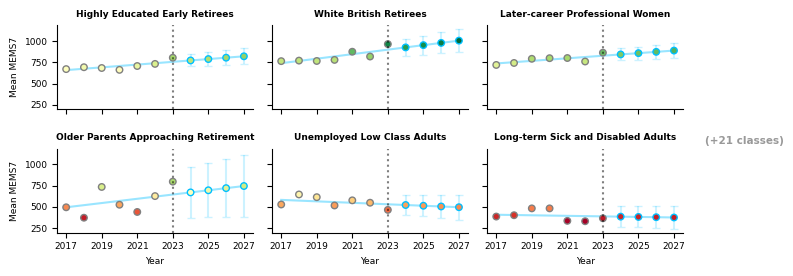

In [66]:
# plot_bayesian_forecast(forecast_df, bayesian_target, highlight=False)
plot_bayesian_forecast(forecast_df, bayesian_target, highlight=True)

# plot_logistic_forecast(logistic_forecast_df, logistic_target, highlight=False)
# plot_logistic_forecast(logistic_forecast_df, logistic_target, highlight=True)